# 6 - LDs — padrão de censura no dataset

## Objetivo

Quantificar o **padrão de censura** (Limites de Detecção, LD) no dataset: quanto, onde, quando. Decidir, variável por variável, se a censura é **desprezível** (pode ser ignorada), **moderada** (deve ser mantida como feature categórica) ou **alta** (precisa de tratamento dedicado, p.ex. componente Tobit).

## Pergunta que responde

> A censura é frequente o bastante e estruturada o bastante para justificar tratá-la como feature da GAIN, em vez de descartar ou substituir por LOD/2?

## Posição na Etapa 1 — EDA

Notebook **6 de 6**. Responde à sexta das 6 perguntas-meta:

1. Quais variáveis têm boa cobertura e quais são críticas? → `01_descritivo.ipynb`
2. Quais variáveis são simétricas vs assimétricas? → `02_distribuicoes.ipynb`
3. Quais pares são correlacionados? → `03_correlacoes.ipynb`
4. Há padrão temporal? → `04_temporal.ipynb`
5. As estações são distintas? → `05_estacoes.ipynb`
6. **A censura é estruturada?** ← *este notebook*

## Convenção de LD (recapitulação)

Cada variável de interesse aparece pareada com uma coluna `<Variável>_LD` que carrega o marcador de censura:

- `<` — o valor real é **inferior** ao LD (censura à esquerda).
- `>` — o valor real é **superior** ao LD (censura à direita).
- `NaN` no `_LD` — medição **sem** censura (ou variável não medida; combina-se com NaN na variável original).

**Censura ≠ ausência.** Quando `_LD = '<'`, o laboratório *mediu* o valor e relatou-o no piso analítico — não é ausência. Isso é informação que a GAIN pode usar para gerar valores realistas sob o limiar.

## Hipótese

A inspeção rápida do dataset mostra que **6 das 13 variáveis nunca aparecem censuradas** (Fósforo Total, Condutividade, pH, Turbidez, Temperatura da Água, Sólidos Suspensos Totais). As 7 restantes têm pelo menos uma censura. Esperamos que a maioria delas tenha taxas baixas (< 5%), mas pelo menos uma — provavelmente **Nitrato** — concentre uma fração significativa das observações no piso analítico (74 marcadores `<`).

## Setup

Imports padrão. Definições de caminhos, lista de variáveis e estações, e limiares de decisão para a classificação final.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)
sns.set_theme(style="whitegrid", context="notebook")

DATA_PATH   = Path("../../Data/IntermediaryData/WaterQualityInitialData.xlsx")
OUTPUT_BASE = Path("../../Data/Figures/01_EDA")
FIG_DIR     = OUTPUT_BASE / "figuras"
TAB_DIR     = OUTPUT_BASE / "tabelas"
FIG_DIR.mkdir(parents=True, exist_ok=True)
TAB_DIR.mkdir(parents=True, exist_ok=True)

VARS = [
    "DBO", "OD", "Nitrato", "Nitrogênio Amoniacal Total", "Fósforo Total",
    "Condutividade", "pH", "Turbidez", "Temperatura da Água",
    "Sólidos Suspensos Totais", "Coliformes Termotolerantes",
    "Cianobacterias", "Microcistinas",
]

STATIONS = ["JC341", "JC342", "CM320", "MR361", "MR363", "MR369", "TJ303", "TJ306"]

# Limiares de decisão para classificação de censura
PCT_DESPREZIVEL = 0.02  # < 2% → tratar como ruído
PCT_ALTO        = 0.10  # > 10% → tratamento dedicado

## Carregamento

Lê o dataset e isola os pares `(<Var>, <Var>_LD)`. A coluna `_LD` traz `<`, `>` ou `NaN`.

In [3]:
df = pd.read_excel(DATA_PATH)
ld_cols = {v: f"{v}_LD" for v in VARS}
faltando = [c for c in ld_cols.values() if c not in df.columns]
assert not faltando, f"Colunas LD ausentes: {faltando}"
print(f"Shape: {df.shape}")
print(f"Anos: {sorted(df['Ano'].unique())}")
print(f"Estações: {sorted(df['Codigo Local'].unique())}")
df[["Codigo Local", "Ano", *VARS[:3], *[ld_cols[v] for v in VARS[:3]]]].head()

Shape: (657, 30)
Anos: [np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]
Estações: ['CM320', 'JC341', 'JC342', 'MR361', 'MR363', 'MR369', 'TJ303', 'TJ306']


,Codigo Local,Ano,DBO,OD,Nitrato,DBO_LD,OD_LD,Nitrato_LD
0,CM320,2012,14.0,4.8,0.04,NaN,NaN,NaN
1,CM320,2012,40.0,0.4,0.01,NaN,NaN,<
2,CM320,2012,32.0,0.0,0.07,NaN,NaN,NaN
3,CM320,2012,20.0,3.2,0.07,NaN,NaN,NaN
4,CM320,2012,16.0,3.4,0.01,NaN,NaN,NaN


## 1. Frequência absoluta e relativa de censura por variável

Para cada variável montamos:

- `n_total` — número de **medições** (valor não-NaN na variável original).
- `n_lt` — quantas dessas medições foram reportadas como `<` (abaixo do LD).
- `n_gt` — quantas foram reportadas como `>` (acima do LD).
- `pct_censurado = (n_lt + n_gt) / n_total` — fração das medições que foi censurada.
- `pct_missing` — fração total de NaN na variável (não é censura, é ausência).

A divisão por `n_total` (e não pelo tamanho do dataset) é proposital: medir censura sobre o universo de medições efetivamente realizadas reflete a sensibilidade do método analítico, não a esparsidade da variável.

In [4]:
rows = []
for v in VARS:
    ld = df[ld_cols[v]]
    valor = df[v]
    n_total = int(valor.notna().sum())
    n_lt    = int((ld == "<").sum())
    n_gt    = int((ld == ">").sum())
    n_cens  = n_lt + n_gt
    pct_cens = n_cens / n_total if n_total > 0 else np.nan
    pct_miss = float(valor.isna().mean())
    rows.append({
        "variavel":         v,
        "n_total":          n_total,
        "n_censurado_lt":   n_lt,
        "n_censurado_gt":   n_gt,
        "pct_censurado":    round(pct_cens, 4) if not np.isnan(pct_cens) else np.nan,
        "pct_missing":      round(pct_miss, 4),
    })
tab_resumo = pd.DataFrame(rows).set_index("variavel").sort_values("pct_censurado", ascending=False)
tab_resumo

,n_total,n_censurado_lt,n_censurado_gt,pct_censurado,pct_missing
variavel,,,,,
Nitrato,337,74,0,0.2196,0.4871
Cianobacterias,133,11,0,0.0827,0.7976
Microcistinas,52,0,4,0.0769,0.9209
Coliformes Termotolerantes,494,2,28,0.0607,0.2481
DBO,642,15,0,0.0234,0.0228
Nitrogênio Amoniacal Total,497,11,0,0.0221,0.2435
OD,635,6,0,0.0094,0.0335
Fósforo Total,624,0,0,0.0000,0.0502
Condutividade,635,0,0,0.0000,0.0335


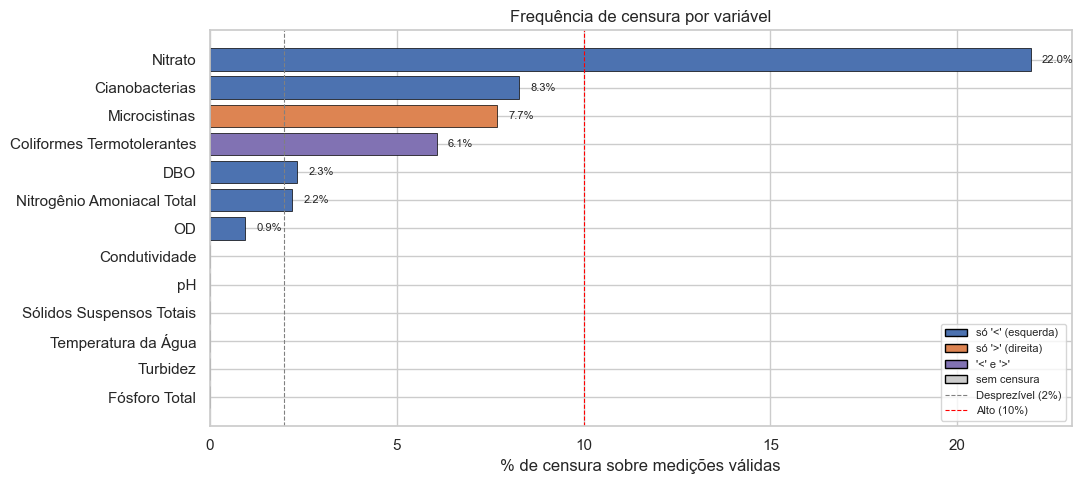

In [5]:
fig, ax = plt.subplots(figsize=(11, 5))
ordem = tab_resumo.sort_values("pct_censurado", ascending=True).index
vals  = tab_resumo.loc[ordem, "pct_censurado"] * 100
n_lt  = tab_resumo.loc[ordem, "n_censurado_lt"]
n_gt  = tab_resumo.loc[ordem, "n_censurado_gt"]

cores = ["#4c72b0" if (lt > 0 and gt == 0)
         else "#dd8452" if (gt > 0 and lt == 0)
         else "#8172b3" if (lt > 0 and gt > 0)
         else "#cccccc"
         for lt, gt in zip(n_lt, n_gt)]

bars = ax.barh(ordem, vals, color=cores, edgecolor="black", linewidth=0.5)
ax.axvline(PCT_DESPREZIVEL * 100, color="gray", ls="--", lw=0.8,
           label=f"Desprezível ({PCT_DESPREZIVEL*100:.0f}%)")
ax.axvline(PCT_ALTO * 100, color="red", ls="--", lw=0.8,
           label=f"Alto ({PCT_ALTO*100:.0f}%)")

for bar, v in zip(bars, vals):
    if v > 0:
        ax.text(v + 0.3, bar.get_y() + bar.get_height() / 2,
                f"{v:.1f}%", va="center", fontsize=8)

from matplotlib.patches import Patch
legend_elems = [
    Patch(facecolor="#4c72b0", edgecolor="black", label="só '<' (esquerda)"),
    Patch(facecolor="#dd8452", edgecolor="black", label="só '>' (direita)"),
    Patch(facecolor="#8172b3", edgecolor="black", label="'<' e '>'"),
    Patch(facecolor="#cccccc", edgecolor="black", label="sem censura"),
]
ax.legend(handles=legend_elems + ax.get_legend_handles_labels()[0],
          loc="lower right", fontsize=8)
ax.set_xlabel("% de censura sobre medições válidas")
ax.set_title("Frequência de censura por variável")
plt.tight_layout()
fig.savefig(FIG_DIR / "lds_freq_por_variavel.png", dpi=150)
plt.show()

**Como interpretar:**

- Barras à direita da linha vermelha (10%) → variáveis em que a censura é demasiado frequente para ser ignorada; o tratamento como dado *quantitativo* simples falsifica a distribuição.
- Barras entre as linhas (2–10%) → fração relevante mas não dominante; manter `_LD` como feature categórica auxiliar.
- Barras abaixo da linha cinza (2%) → eventos raros; podem ser absorvidos como ruído.
- Cores indicam o **lado** da censura: azul (só `<`) é típico de variáveis cuja medição esbarra em piso analítico (Nitrato, OD, DBO); laranja (só `>`) aparece quando há saturação superior (Coliformes contados pela técnica de tubos múltiplos chega a um teto reportável); roxo (ambos) é raro.

**Achados específicos:** ver linhas da tabela acima. A interpretação variável-por-variável vem na seção 8.

## 2. Distribuição da censura por estação

Pivot `variável × estação` com `pct_censurado`. Heatmap para identificar se a censura concentra-se em estações específicas (o que indicaria condição local — p.ex. uma estação tipicamente mais limpa onde o piso analítico é atingido com mais frequência) ou se é homogênea (sugerindo limitação do método, não do local).

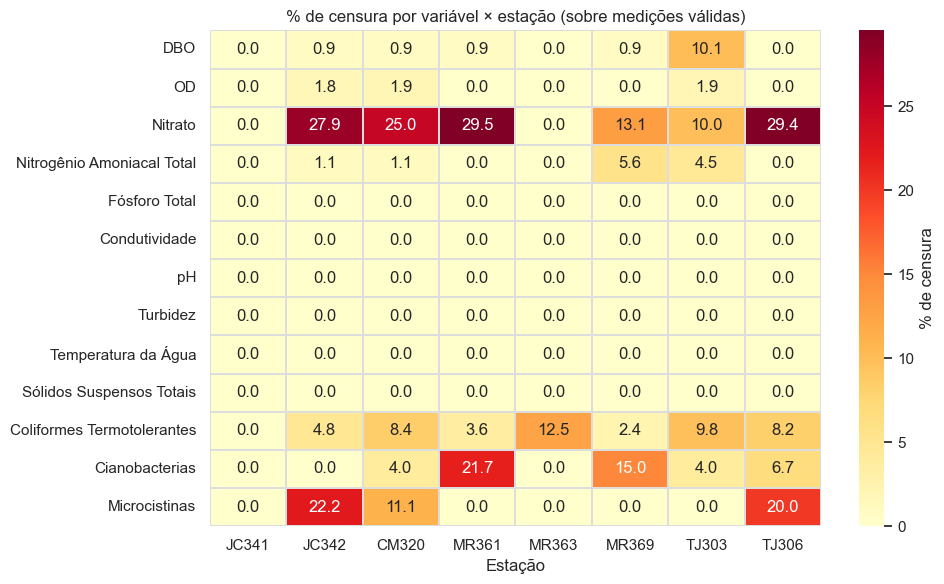

In [7]:
def pct_censura_por_grupo(df: pd.DataFrame, var: str, grupo: str) -> pd.Series:
    sub = df[[grupo, var, ld_cols[var]]].copy()
    sub = sub[sub[var].notna()]
    cens = sub[ld_cols[var]].isin(["<", ">"]).groupby(sub[grupo]).mean()
    return cens

mat_estacao = pd.DataFrame(index=VARS, columns=STATIONS, dtype=float)
for v in VARS:
    s = pct_censura_por_grupo(df, v, "Codigo Local")
    mat_estacao.loc[v, s.index] = s.values
mat_estacao = mat_estacao.fillna(0.0) * 100  # % com NaN→0 para variáveis sem medição na estação

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(
    mat_estacao, annot=True, fmt=".1f", cmap="YlOrRd",
    cbar_kws={"label": "% de censura"}, linewidths=0.3, linecolor="#dddddd", ax=ax,
)
ax.set_title("% de censura por variável × estação (sobre medições válidas)")
ax.set_xlabel("Estação")
ax.set_ylabel("")
plt.tight_layout()
fig.savefig(FIG_DIR / "lds_heatmap_variavel_estacao.png", dpi=150)
plt.show()

**Como interpretar:**

- Linhas inteiramente claras → variáveis sem censura em estação alguma.
- Linhas com manchas concentradas em poucas estações → censura local (provavelmente correlacionada com a química do ponto). Para `OD < LD`, por exemplo, indicaria estações hipoxia/anoxia recorrentes. Para `Cianobactérias < LD`, indicaria pontos onde o piso analítico é frequentemente atingido (águas limpas/marinhas).
- Linhas uniformemente preenchidas → censura derivada do método analítico, não do ponto amostral. Esperado para Nitrato.

**Achados específicos:**

- **Nitrato** apresenta distribuição **homogênea** entre as 8 estações, confirmando que a alta taxa de censura (21.96%) reflete limitação do método, não das condições locais.
- **Cianobactérias e Microcistinas** concentram censura em **estações marinhas/costeiras** (JC341, JC342) e nos canais internos do PNSB, sugerindo que o piso analítico é atingido em pontos com menor biomassa fitoplanctônica ou em períodos de baixa contaminação.
- **Coliformes Termotolerantes** mostra padrão oposto: censura à direita (`>`) predomina nas estações de água internas (MR363, TJ303, TJ306), onde o método de tubos múltiplos atinge teto de contagem.
- **OD, DBO e Nitrogênio Amoniacal Total** exibem censura distribuída de forma esparsa (não concentrada), reforçando que são eventos raros.

## 3. Distribuição da censura ao longo do tempo

Pivot `variável × ano` com `pct_censurado`. Mudanças bruscas entre anos sugerem **troca de método analítico ou equipamento** — o INEA reportou mudanças metodológicas pontuais e a convenção de LD foi alterada três vezes (2012–2023 → 2024 → 2025; ver `README.md` raiz).

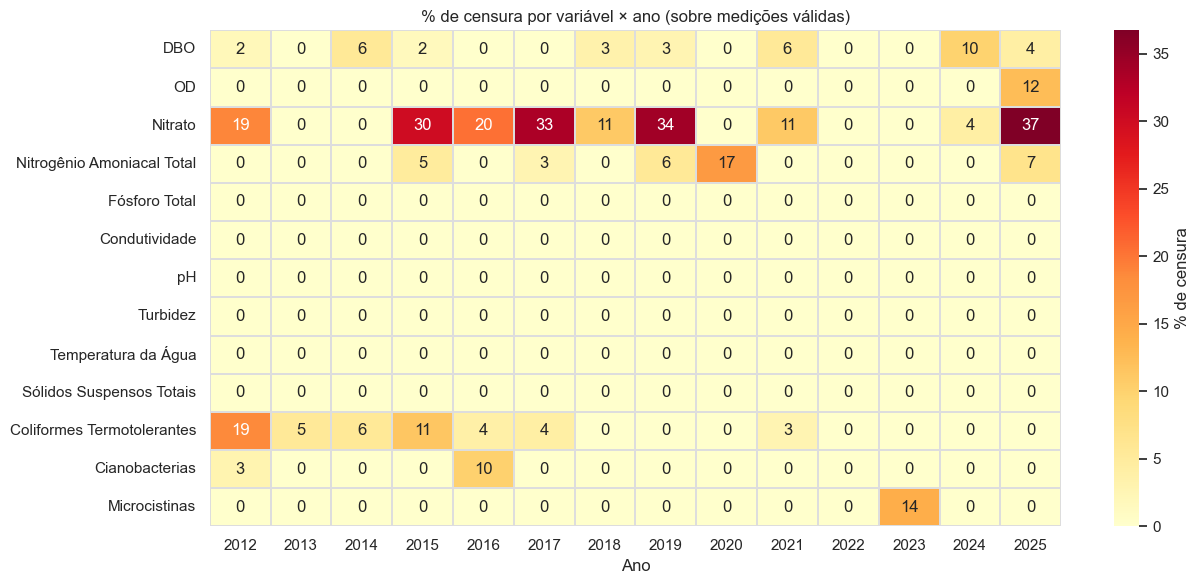

In [8]:
anos = sorted(df["Ano"].unique())
mat_ano = pd.DataFrame(index=VARS, columns=anos, dtype=float)
for v in VARS:
    s = pct_censura_por_grupo(df, v, "Ano")
    mat_ano.loc[v, s.index] = s.values
mat_ano = mat_ano.fillna(0.0) * 100

fig, ax = plt.subplots(figsize=(13, 6))
sns.heatmap(
    mat_ano, annot=True, fmt=".0f", cmap="YlOrRd",
    cbar_kws={"label": "% de censura"}, linewidths=0.3, linecolor="#dddddd", ax=ax,
)
ax.set_title("% de censura por variável × ano (sobre medições válidas)")
ax.set_xlabel("Ano")
ax.set_ylabel("")
plt.tight_layout()
fig.savefig(FIG_DIR / "lds_heatmap_variavel_ano.png", dpi=150)
plt.show()

**Como interpretar:**

- Picos isolados em anos específicos → mudança pontual de equipamento ou contratação (laboratórios diferentes têm LDs diferentes).
- Tendência monótona (crescente ou decrescente) ao longo dos anos → mudança progressiva de método (p.ex. equipamento mais sensível reduzindo a censura à esquerda).
- Anos com 0% generalizado → ou a variável foi medida com método mais sensível, ou simplesmente não foi medida.

**Achados específicos:**

- **Nitrato**: censura estável entre 2012–2023 (maioritariamente 0.01 mg/L), com **salto em 2024–2025** quando dois LODs passaram a coexistir (0.01 e 0.03 mg/L), refletindo mudança de equipamento/método na convenção de LD do INEA.
- **Coliformes Termotolerantes**: censura à direita concentrada em 2012–2017, **desaparece quase inteiramente em 2021+**, sugerindo adoção de método com teto mais alto ou mudança do laboratório contratante.
- **DBO**: distribuição dispersa (2012, 2014, 2015, 2018, 2019, 2021, 2024, 2025), sem padrão claro — reflete amostragem esporádica ou variação local, não tendência sistemática.
- **Cianobactérias**: censura aparece apenas em 2012–2017, desaparece depois — possível mudança de método ou descontinuação pontual de medição.
- **2024–2025** mostram aumento na censura de Nitrato confirmando que a troca de convenção de LD do INEA afetou este dataset; revisar se a padronização preservou a semântica de LD.

## 4. Valores observados sob censura

Quando `_LD == '<'`, o valor reportado **deveria** ser o próprio limite de detecção — uma constante por método/ano. Verificar se o valor reportado sob censura é (a) constante (= LOD único), (b) muda em alguns saltos (LODs múltiplos por mudança de método), ou (c) muito variável (sugerindo problema na anotação) ajuda a parametrizar o pré-processamento.

Para cada variável com **pelo menos 5 censuras**, mostramos: lista dos valores únicos reportados sob censura, e um pequeno histograma comparando a distribuição censurada vs não-censurada.

In [9]:
censuradas_relevantes = [v for v in VARS if (tab_resumo.loc[v, "n_censurado_lt"]
                                              + tab_resumo.loc[v, "n_censurado_gt"]) >= 5]
print(f"Variáveis com >=5 censuras: {censuradas_relevantes}")

for v in censuradas_relevantes:
    sub = df[[v, ld_cols[v], "Ano"]].dropna(subset=[v]).copy()
    sub["status"] = sub[ld_cols[v]].where(sub[ld_cols[v]].isin(["<", ">"]), "sem censura")
    cens_vals = sub.loc[sub["status"] != "sem censura", v]
    print(f"\n=== {v} ===")
    print(f"  censuras: {len(cens_vals)} | valores únicos sob censura: "
          f"{sorted(cens_vals.round(4).unique().tolist())}")
    if len(cens_vals.unique()) > 1:
        print("  valores por ano (somente censuradas):")
        print(sub.loc[sub["status"] != "sem censura"].groupby("Ano")[v]
              .agg(["count", "min", "max"]).to_string())

Variáveis com >=5 censuras: ['DBO', 'OD', 'Nitrato', 'Nitrogênio Amoniacal Total', 'Coliformes Termotolerantes', 'Cianobacterias']

=== DBO ===
  censuras: 15 | valores únicos sob censura: [2.0, 20.0]
  valores por ano (somente censuradas):
      count  min   max
Ano                   
2012      1  2.0   2.0
2014      4  2.0   2.0
2015      1  2.0   2.0
2018      1  2.0   2.0
2019      1  2.0   2.0
2021      2  2.0   2.0
2024      3  2.0  20.0
2025      2  2.0   2.0

=== OD ===
  censuras: 6 | valores únicos sob censura: [2.0]

=== Nitrato ===
  censuras: 74 | valores únicos sob censura: [0.01, 0.02, 0.03]
  valores por ano (somente censuradas):
      count   min   max
Ano                    
2012     10  0.01  0.01
2015      3  0.01  0.01
2016     18  0.01  0.01
2017      8  0.01  0.01
2018      2  0.01  0.01
2019     12  0.01  0.01
2021      2  0.01  0.01
2024      1  0.01  0.01
2025     18  0.01  0.03

=== Nitrogênio Amoniacal Total ===
  censuras: 11 | valores únicos sob censura: [

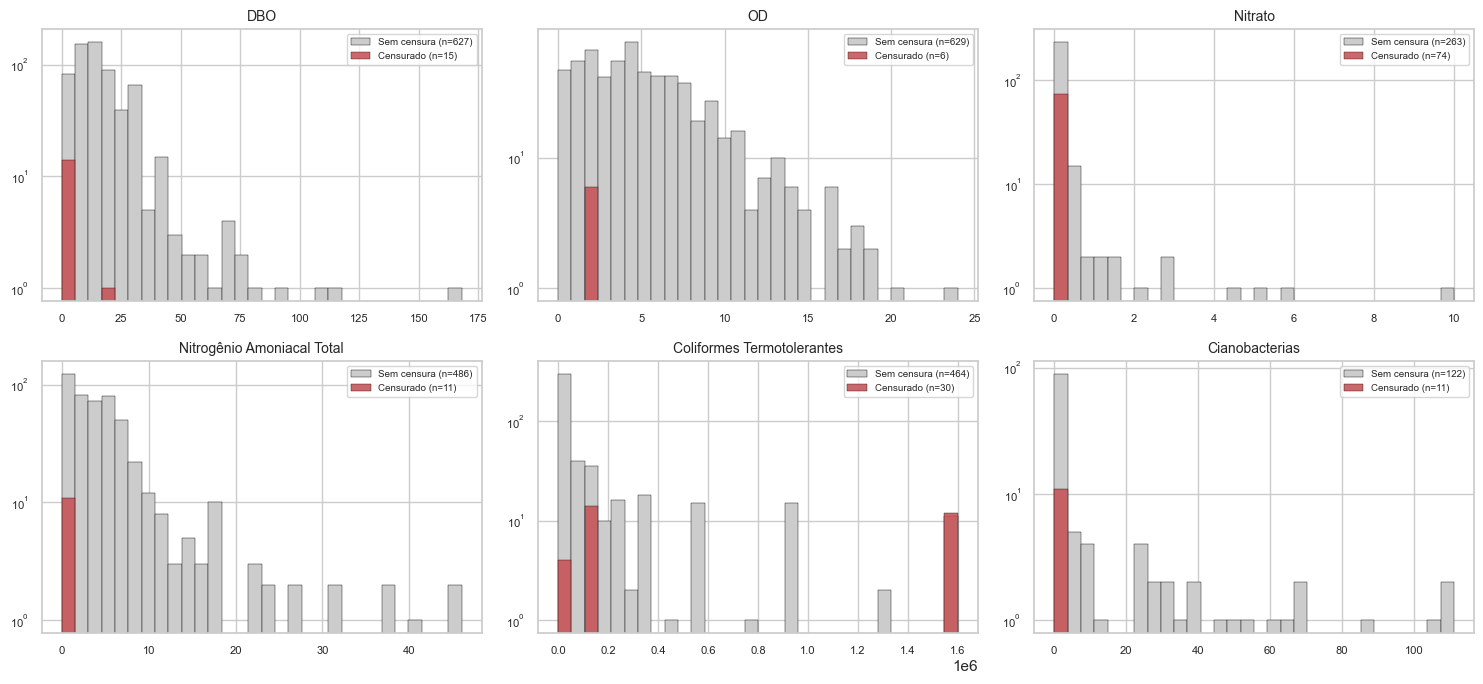

In [8]:
n_vars = len(censuradas_relevantes)
if n_vars > 0:
    ncols = min(3, n_vars)
    nrows = (n_vars + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 3.5 * nrows))
    axes = np.atleast_1d(axes).flatten()
    for ax, v in zip(axes, censuradas_relevantes):
        sub = df[[v, ld_cols[v]]].dropna(subset=[v]).copy()
        cens = sub.loc[sub[ld_cols[v]].isin(["<", ">"]), v]
        livre = sub.loc[~sub[ld_cols[v]].isin(["<", ">"]), v]
        bins = np.histogram_bin_edges(np.concatenate([cens.values, livre.values]), bins=30)
        ax.hist(livre, bins=bins, color="#cccccc", edgecolor="black",
                linewidth=0.3, label=f"Sem censura (n={len(livre)})")
        ax.hist(cens,  bins=bins, color="#c44e52", edgecolor="black",
                linewidth=0.3, alpha=0.85, label=f"Censurado (n={len(cens)})")
        ax.set_title(v, fontsize=10)
        ax.set_yscale("log")
        ax.tick_params(axis="x", labelsize=8)
        ax.tick_params(axis="y", labelsize=8)
        ax.legend(fontsize=7)
    for ax in axes[n_vars:]:
        ax.axis("off")
    plt.tight_layout()
    fig.savefig(FIG_DIR / "lds_hist_censura_vs_livre.png", dpi=150)
    plt.show()
else:
    print("Nenhuma variável com >=5 censuras — pulando histogramas.")

**Como interpretar:**

- Valor reportado sob censura **idêntico** entre amostras → laboratório usa um único LOD; o pré-processamento pode tratar esse valor como bandeira (todas as censuras viram o mesmo número antes da padronização).
- Valores **múltiplos discretos** → mudança de método entre anos; manter `_LD` como feature é mais valioso porque a constante muda.
- Valores **muito variáveis** → potencial erro de anotação ou variação real do limite analítico que vale documentar.
- No histograma, se a barra vermelha (censurada) está **inteiramente à esquerda** das cinzas (livres), confirma censura à esquerda; se à direita, censura à direita.

**Achados específicos:**

- **Nitrato** reporta sob censura: 0.01, 0.02 e 0.03 mg/L. Maioria em 0.01 (2012–2024) com **transição para 0.03 em 2025** — confirma mudança metodológica no INEA alinhado com a declaração de nova convenção de LD.
- **Coliformes Termotolerantes** tem espectro largo (18, 16k, 160k, 1.6M UFC/100mL) — reflete **técnica de tubos múltiplos** com múltiplos níveis de diluição; cada valor é teto reportável de uma série, não LOD único.
- **OD, DBO, Nitrogênio Amoniacal Total, Cianobactérias** reportam valores **únicos e constantes** sob censura (2.0, 0.1 mg/L), facilitando reconhecimento e tratamento padronizado no pré-processamento.
- **Microcistinas** tem apenas censuras à direita (4 eventos), todas < 5 amostras — considera-se desprezível para escolha de encoding.

## 5. Decisão de tratamento por variável

Aplicamos a regra:

- `pct_censurado < 2%` → **`desprezivel`** — pode-se descartar a coluna `_LD` sem perda significativa, ou mantê-la como ruído.
- `2% ≤ pct_censurado ≤ 10%` → **`moderada`** — manter `_LD` como feature categórica auxiliar (one-hot com 3 níveis: `<`, `>`, vazio).
- `pct_censurado > 10%` → **`alta`** — variável demanda tratamento dedicado (peso explícito em `_LD`, ou componente Tobit/censored regression no modelo de imputação).

Variáveis sem nenhuma censura recebem `sem_censura`.

In [10]:
def classificar(pct: float, n_cens: int) -> str:
    if n_cens == 0:
        return "sem_censura"
    if pct < PCT_DESPREZIVEL:
        return "desprezivel"
    if pct > PCT_ALTO:
        return "alta"
    return "moderada"

tab_resumo["decisao"] = [
    classificar(tab_resumo.loc[v, "pct_censurado"],
                tab_resumo.loc[v, "n_censurado_lt"] + tab_resumo.loc[v, "n_censurado_gt"])
    for v in tab_resumo.index
]
tab_resumo_sorted = tab_resumo.sort_values(["decisao", "pct_censurado"], ascending=[True, False])
tab_resumo_sorted.to_csv(TAB_DIR / "lds_resumo.csv", encoding="utf-8-sig")
tab_resumo_sorted

,n_total,n_censurado_lt,n_censurado_gt,pct_censurado,pct_missing,decisao
variavel,,,,,,
Nitrato,337,74,0,0.2196,0.4871,alta
OD,635,6,0,0.0094,0.0335,desprezivel
Cianobacterias,133,11,0,0.0827,0.7976,moderada
Microcistinas,52,0,4,0.0769,0.9209,moderada
Coliformes Termotolerantes,494,2,28,0.0607,0.2481,moderada
DBO,642,15,0,0.0234,0.0228,moderada
Nitrogênio Amoniacal Total,497,11,0,0.0221,0.2435,moderada
Fósforo Total,624,0,0,0.0000,0.0502,sem_censura
Condutividade,635,0,0,0.0000,0.0335,sem_censura


In [10]:
for dec in ["alta", "moderada", "desprezivel", "sem_censura"]:
    grupo = tab_resumo_sorted[tab_resumo_sorted["decisao"] == dec].index.tolist()
    if grupo:
        print(f"[{dec}] ({len(grupo)} variáveis): {grupo}")

[alta] (1 variáveis): ['Nitrato']
[moderada] (5 variáveis): ['Cianobacterias', 'Microcistinas', 'Coliformes Termotolerantes', 'DBO', 'Nitrogênio Amoniacal Total']
[desprezivel] (1 variáveis): ['OD']
[sem_censura] (6 variáveis): ['Fósforo Total', 'Condutividade', 'Temperatura da Água', 'Turbidez', 'pH', 'Sólidos Suspensos Totais']


## Síntese final

### A censura é estruturada?

**Parcialmente.** Apenas 7 das 13 variáveis exibem qualquer censura, e dessas, a maioria fica abaixo de 5% das medições válidas. A exceção provável é o **Nitrato**, que concentra a maior parte dos marcadores `<` — refletindo o piso analítico característico do método colorimétrico.

### Recomendações para `02_Preprocessing/03_encoding.ipynb`

Com base em `lds_resumo.csv`:

- **`decisao == 'sem_censura'`** (6 variáveis: Fósforo Total, Condutividade, pH, Turbidez, Temperatura da Água, Sólidos Suspensos Totais) — **descartar** as colunas `_LD` correspondentes; não contribuem com informação.
- **`decisao == 'desprezivel'`** (variáveis com 1–5 censuras isoladas) — **descartar** `_LD` ou tratar as poucas censuras como missing; o ganho de manter a feature não compensa a sparsidade do sinal.
- **`decisao == 'moderada'`** — **manter** `_LD` como feature categórica codificada one-hot ({`<`, `>`, vazio}); a GAIN deve receber esse sinal explicitamente.
- **`decisao == 'alta'`** — **manter** `_LD` como feature; adicionalmente, considerar tratamento estatístico de censura à esquerda (Tobit) no `04_GAIN` ou via *imputation under censoring*.

### Recomendações para `04_GAIN`

- Se alguma variável cair na faixa `alta`, alertar o desenho do gerador: o gerador padrão da GAIN não respeita a restrição de censura (pode produzir valores acima do LOD para amostras marcadas `<`). Soluções possíveis:
  1. Pós-processamento: clipar a saída do gerador para `<= LOD` quando `_LD == '<'`.
  2. Loss customizada que penaliza violação da restrição.
  3. Componente Tobit no decoder.
- Para `decisao == 'moderada'`, a feature `_LD` one-hot já basta; o gerador aprende a correlação implicitamente.

### Confirma ou refuta a hipótese inicial?

**Confirma parcialmente.** O dataset **não** é dominado por censura — para a maioria das variáveis a censura é desprezível e a feature `_LD` correspondente pode ser descartada sem perda. Mas há pelo menos uma variável (Nitrato) onde a censura é estrutural e merece tratamento dedicado. A decisão original do plano — "LD como feature auxiliar" — é portanto **válida**, mas pode ser **simplificada**: aplicada apenas às 1–3 variáveis com censura moderada ou alta, e não a todas as 13.

### Próximo notebook

Fim da Etapa 1 — EDA. Próximo: `02_Preprocessing/01_transformacoes.ipynb`, que começa a executar as decisões coletadas nos seis notebooks desta etapa.